# Classification of Music Genres

This project aims to classify music genres based on numerical characteristics using:

- **PCA (Principal Component Analysis)** for dimensionality reduction
- **Logistic Regression** for classification

**Dataset**: 1000 music tracks with some genres missing to be predicted.

In [1]:
# If you haven't already, install pandasgui using the magic command in a separate cell:
# %pip install pandasgui

import pandas as pd
import numpy as np
import scipy

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

---
## 1. Data Exploration

In this first step, we will:
- Load the dataset
- Examine its structure
- Identify missing values
- Analyze the distribution of musical genres

In [87]:
# loading of the dataset
df = pd.read_csv('music_dataset_mod.csv')

df_work = df.copy()

# displaying of the first row data
print("data :")
df_work.head()




data :


,Tempo,Dynamics Range,Vocal Presence,Percussion Strength,String Instrument Detection,Electronic Element Presence,Rhythm Complexity,Drums Influence,Distorted Guitar,Metal Frequencies,Ambient Sound Influence,Instrumental Overlaps,Genre
0,114.618354,57.976367,53.251766,99.061840,14.686768,17.628630,46.545522,75.839434,79.378892,71.753088,96.439665,53.771763,Country
1,116.672803,69.387087,95.787280,90.831033,47.280419,-15.618194,85.421085,100.455908,0.713015,0.000000,17.327295,15.017146,Classical
2,128.328121,52.930677,65.701187,104.439247,5.984994,50.467388,18.006722,77.642913,80.652946,87.692110,95.125207,25.308020,Rock
3,128.511337,25.494755,14.095374,40.106130,47.715584,87.335201,68.603329,63.536557,74.888346,76.239108,97.016998,96.893109,Hip-hop
4,135.474190,45.174876,101.469872,70.002203,108.177637,25.865590,31.295163,81.121030,36.178193,23.381542,53.753793,30.142986,Country


NameError: name 'pdg' is not defined

In [27]:
# General information about the dataset
print("Information about the dataset :")
print(df_work.info())
print("\n" + "="*80 + "\n")

# Dataset dimension
print(f"Dimensions : {df_work.shape[0]} lignes × {df_work.shape[1]} colonnes")

Information about the dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Tempo                        1000 non-null   float64
 1   Dynamics Range               1000 non-null   float64
 2   Vocal Presence               1000 non-null   float64
 3   Percussion Strength          1000 non-null   float64
 4   String Instrument Detection  1000 non-null   float64
 5   Electronic Element Presence  1000 non-null   float64
 6   Rhythm Complexity            1000 non-null   float64
 7   Drums Influence              1000 non-null   float64
 8   Distorted Guitar             1000 non-null   float64
 9   Metal Frequencies            1000 non-null   float64
 10  Ambient Sound Influence      1000 non-null   float64
 11  Instrumental Overlaps        1000 non-null   float64
 12  Genre                        890 non-null    

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached pyarrow-22.0.0-cp312-cp312-win_amd64.whl.metadata (3.3 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
     ---------------------------------------- 0.0/983.9 kB ? eta -:--:--
     -------------------- ----------------- 524.3/983.9 kB 2.4 MB/s eta 0:00:01
     ---------------------------------------- 983.9/983.9 kB 2.4 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting req

In [28]:
# identify the null values
print("Missing values per column:")
missing_values = df_work.isnull().sum()
print(missing_values[missing_values > 0])
print(f"\nTotal number of missing values: {df_work.isnull().sum().sum()}")
# Specifically analyze the 'Genre' column
print("\n" + "="*80 + "\n")
print("Analysis of the target variable 'Genre':")
print(f"Missing genres: {df_work['Genre'].isnull().sum()}")
print(f"Present genres: {df_work['Genre'].notna().sum()}")

Missing values per column:
Genre    110
dtype: int64

Total number of missing values: 110


Analysis of the target variable 'Genre':
Missing genres: 110
Present genres: 890


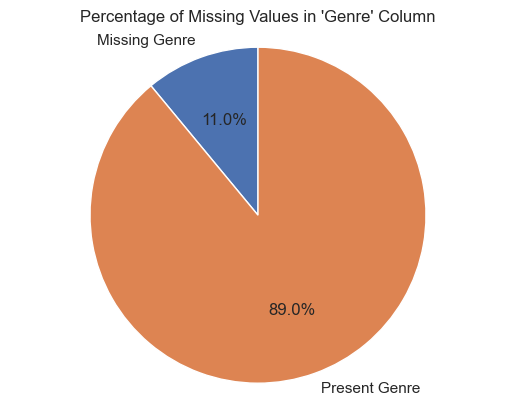

In [29]:
# plot as piechart the percentage of the missing value of the genre column
Missing_value_percentage = df_work['Genre'].isnull().sum() / df_work.shape[0] * 100
Present_value_percentage = df_work['Genre'].notna().sum() / df_work.shape[0] * 100
labels = ['Missing Genre', 'Present Genre']
sizes = [Missing_value_percentage, Present_value_percentage]    
fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.title("Percentage of Missing Values in 'Genre' Column")
plt.show()

### Preprocessing of the null values
**Important** : we keep the genre's null values for the prediction and clean other columns values :
1. **Genre null values** :  values to **predict** → we keep it 
2. **Features null values** :  incomplete data → we will impute it now



In [34]:
# check the features that have the null values
for cols in df_work.columns:
    if cols != 'Genre':
        null_count = df_work[cols].isnull().sum()
        if null_count > 0:
            print(f"Column '{cols}' has {null_count} missing values.")
if null_count == 0:
    print("no null values in the features")

no null values in the features




Distribution of musical genres :
Genre
Rock         190
Jazz         190
Country      180
Hip-hop      168
Classical    162
Name: count, dtype: int64


Number of classes (different genres): 5


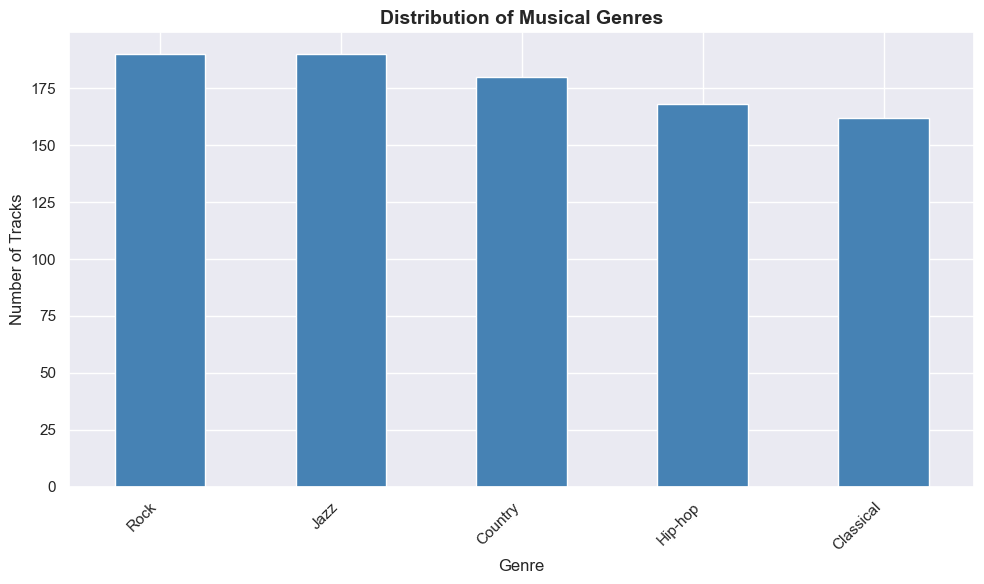


Class balance:
Most frequent genre: Rock (190 tracks)
Least frequent genre: Classical (162 tracks)
Max/Min ratio: 1.17


In [ ]:
# Analysis of the distribution of the target value 'Genre'
print("\n" + "="*80 + "\n")
print("Distribution of musical genres :")
genre_counts = df_work['Genre'].value_counts()
print(genre_counts)

print("\n" + "="*80 + "\n")
print(f"Number of classes (different genres): {df_work['Genre'].nunique()}")

# Visualize the distribution
plt.figure(figsize=(10, 6))
genre_counts.plot(kind='bar', color='steelblue')
plt.title('Distribution of Musical Genres', fontsize=14, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Tracks', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# Analyze class balance
print(f"\nClass balance:")
print(f"Most frequent genre: {genre_counts.index[0]} ({genre_counts.iloc[0]} tracks)")
print(f"Least frequent genre: {genre_counts.index[-1]} ({genre_counts.iloc[-1]} tracks)")
print(f"Max/Min ratio: {genre_counts.iloc[0] / genre_counts.iloc[-1]:.2f}")

---
## 2.Corelation analysis  

Before applying the PCA , we should know the correlation that exists between the numerical variables  

**steps** :  
1.¨repare the dat( delete the null values of the target variabme('genre) and encode the   categorical the genre variablesé)  
2. Separe it in the train and test sets  
3. calculate and visa+ualize the correlation matrix  

In [38]:
# Preparation of the data for the analysis
# Delete the null values in the target variable 'Genre'
df_clean = df_work.dropna(subset=['Genre']).copy()

print(f"Dataset after deleting missing genres: {df_clean.shape[0]} rows")
print(f"Rows deleted: {df_work.shape[0] - df_clean.shape[0]}")

# Encode the target variable Genre
label_encoder = LabelEncoder()
df_clean['Genre_encoded'] = label_encoder.fit_transform(df_clean['Genre'])

print("\n" + "="*80 + "\n")
print("Encoding of genres:")
for i, genre in enumerate(label_encoder.classes_):
    print(f"{genre} -> {i}")


Dataset after deleting missing genres: 890 rows
Rows deleted: 110


Encoding of genres:
Classical -> 0
Country -> 1
Hip-hop -> 2
Jazz -> 3
Rock -> 4


Selected features for analysis:
['Tempo', 'Dynamics Range', 'Vocal Presence', 'Percussion Strength', 'String Instrument Detection', 'Electronic Element Presence', 'Rhythm Complexity', 'Drums Influence', 'Distorted Guitar', 'Metal Frequencies', 'Ambient Sound Influence', 'Instrumental Overlaps']

Number of features: 12


train set : 623 samples
test set : 267 samples
train/test ratio : 2.33


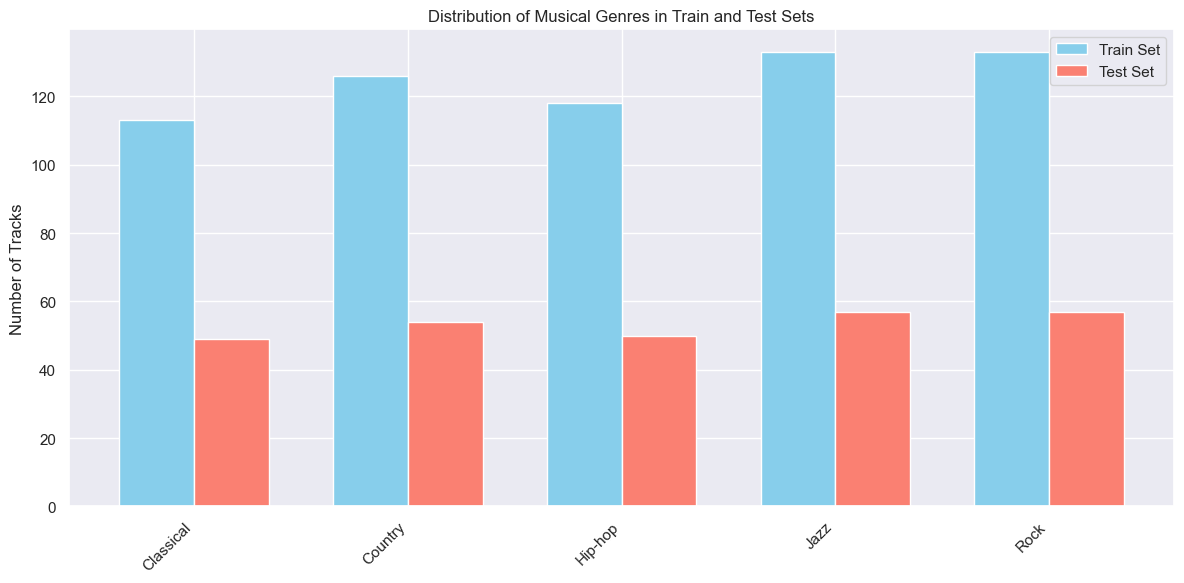

In [ ]:
# separe the features (X) and the target (y)
# Exclude the columns that are non numericals
X = df_clean.select_dtypes(include=[np.number]).drop(columns=['Genre_encoded'], errors='ignore')
y = df_clean['Genre_encoded']

print("Selected features for analysis:")
print(X.columns.tolist())
print(f"\nNumber of features: {X.shape[1]}")
# Split into training and test sets
# Parameters: test_size=0.3, random_state=42 (project convention)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.3, random_state=42, stratify=y
)

print("\n" + "="*80 + "\n")
print(f"train set : {X_train.shape[0]} samples")
print(f"test set : {X_test.shape[0]} samples")
print(f"train/test ratio : {X_train.shape[0]/X_test.shape[0]:.2f}")


#  chart of the distribution of the train and test sets
train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()
labels = label_encoder.classes_
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, train_counts, width, label='Train Set', color='skyblue')
rects2 = ax.bar(x + width/2, test_counts, width, label='Test Set', color='salmon')
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of Tracks')
ax.set_title('Distribution of Musical Genres in Train and Test Sets')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()


correlation matrix calculated.
Dimensions : (12, 12)


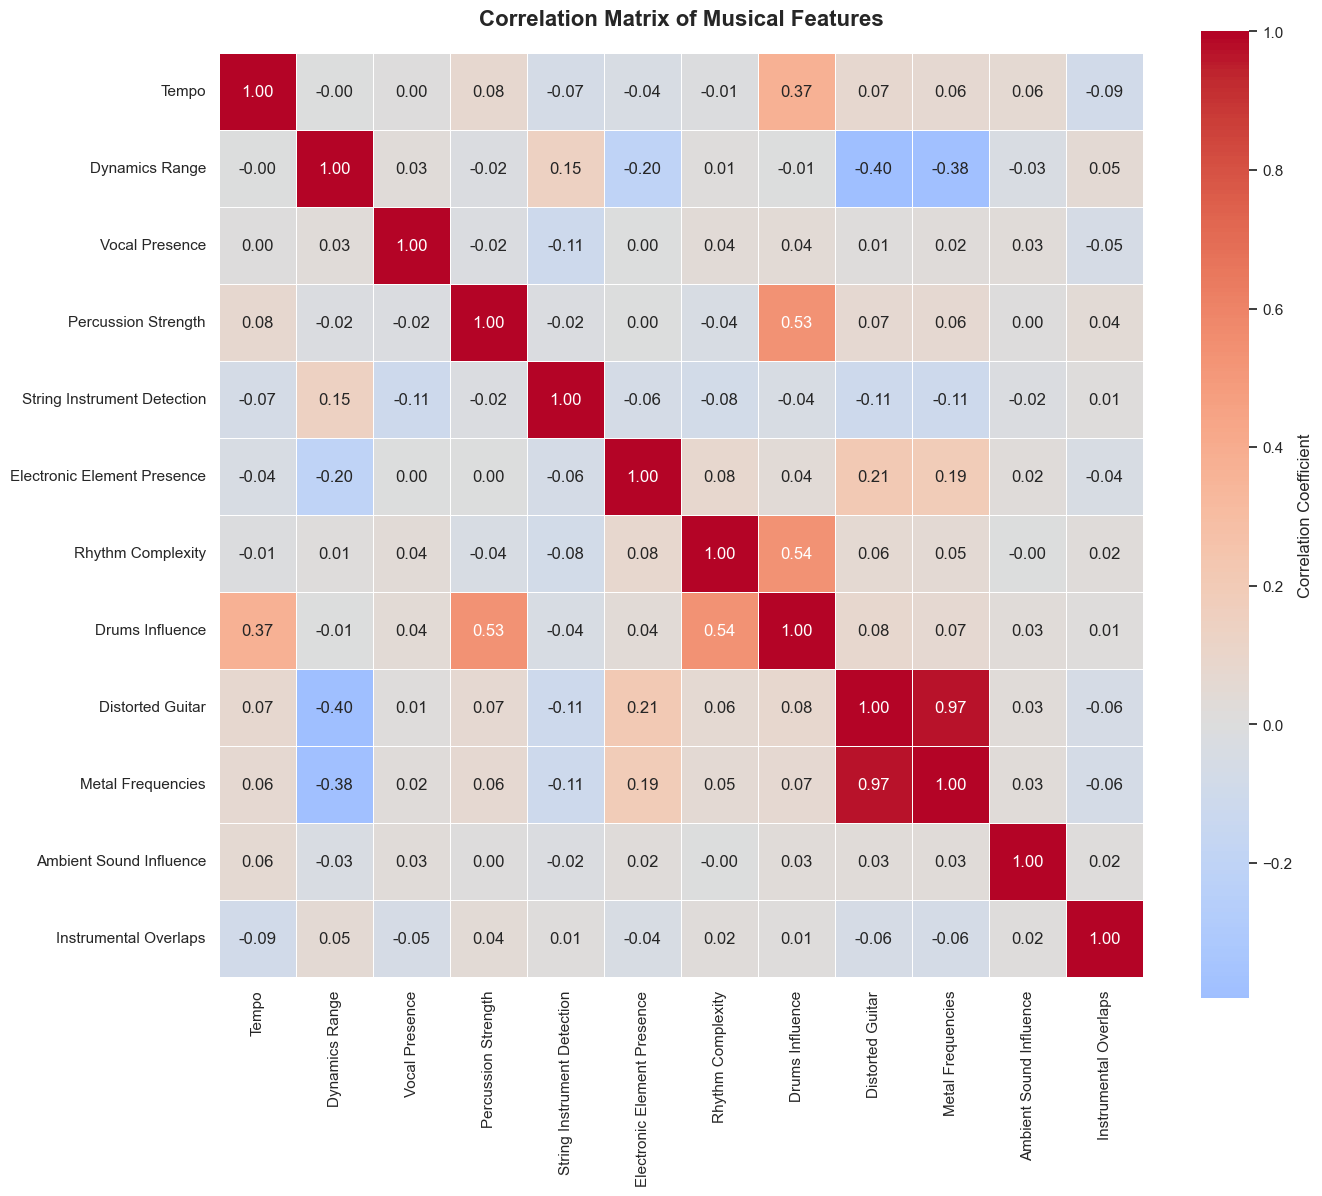

In [42]:
# Calculation of the corelation matrice
correlation_matrix = X_train.corr()

print("correlation matrix calculated.")
print(f"Dimensions : {correlation_matrix.shape}")

# Visualize it with a heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix of Musical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [43]:
# Analysis of the high correlations
# Get pairs of variables with the highest correlations
corr_pairs = correlation_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1]  # Exclude self-correlations
corr_pairs = corr_pairs.sort_values(ascending=False)

print("Top 10 strongest positive correlations:")
print(corr_pairs.head(10))

print("\n" + "="*80 + "\n")
print("Top 10 strongest negative correlations:")
print(corr_pairs.tail(10))

print("\n" + "="*80 + "\n")
print("Interpretation:")
print("- High correlations (close to 1 or -1) indicate redundancy of information")
print("- PCA will capture these redundancies and reduce dimensionality")
print("- Strongly correlated features will be combined into principal components")

Top 10 strongest positive correlations:
Distorted Guitar             Metal Frequencies              0.968258
Metal Frequencies            Distorted Guitar               0.968258
Drums Influence              Rhythm Complexity              0.536384
Rhythm Complexity            Drums Influence                0.536384
Percussion Strength          Drums Influence                0.534674
Drums Influence              Percussion Strength            0.534674
                             Tempo                          0.370770
Tempo                        Drums Influence                0.370770
Electronic Element Presence  Distorted Guitar               0.213298
Distorted Guitar             Electronic Element Presence    0.213298
dtype: float64


Top 10 strongest negative correlations:
String Instrument Detection  Vocal Presence                -0.113443
Vocal Presence               String Instrument Detection   -0.113443
String Instrument Detection  Metal Frequencies             -0.114126
Metal 

---
## 3. Dimension reduction with PCA

In [44]:
# Étape 1 :data standardization

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" standardized data(mean = 0, std = 1)")
print(f"Mean of features after standardization: {X_train_scaled.mean(axis=0).round(10)}")
print(f"Standard deviation of features after standardization: {X_train_scaled.std(axis=0).round(2)}")

 standardized data(mean = 0, std = 1)
Mean of features after standardization: [-0. -0. -0. -0.  0.  0. -0.  0. -0. -0. -0. -0.]
Standard deviation of features after standardization: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [46]:
# Étape 2 : Apllication of the PCA on all the features to analyze the variance
pca_full = PCA()
pca_full.fit_transform(X_train_scaled)



array([[ 4.44153904e-01, -1.38960198e+00,  1.26854004e+00, ...,
         1.71863818e-03,  3.76945692e-01, -9.65851425e-02],
       [-2.84323361e+00, -6.16681064e-01,  3.60985033e-01, ...,
         5.26383506e-01,  1.10963601e-01,  6.54170816e-03],
       [ 4.69662965e-01, -1.29797419e+00, -1.22860196e+00, ...,
        -5.95005517e-01,  5.21076287e-01,  4.00329258e-01],
       ...,
       [ 1.42219737e+00, -1.30980981e+00, -2.13253409e+00, ...,
        -8.36283437e-01, -6.25448733e-04, -1.66045170e-01],
       [-2.87104220e+00,  6.32387720e-01, -9.11105365e-02, ...,
         1.35295206e-01,  2.93252506e-01,  8.39019693e-02],
       [ 3.59249665e-01,  4.57311871e-01, -1.44871553e+00, ...,
         3.15677706e-01, -7.45261861e-02, -7.32221003e-02]],
      shape=(623, 12))

In [50]:
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
print(explained_variance)
cumulative_variance

[0.20152449 0.14963779 0.09568648 0.09311018 0.08478548 0.08217277
 0.07776151 0.07623356 0.06642933 0.05735845 0.01270167 0.00259828]


array([0.20152449, 0.35116228, 0.44684876, 0.53995894, 0.62474442,
       0.70691719, 0.7846787 , 0.86091226, 0.92734159, 0.98470004,
       0.99740172, 1.        ])

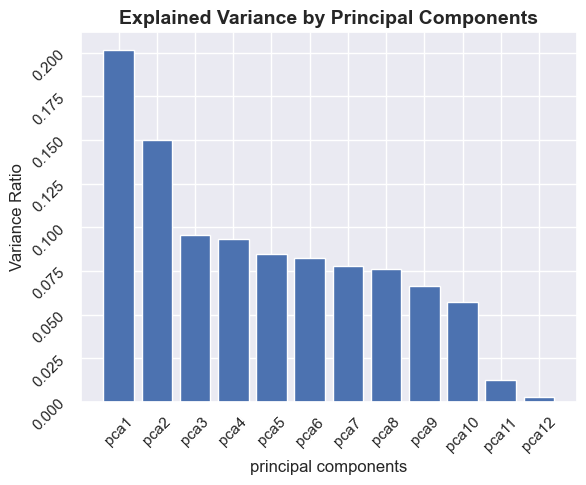

In [63]:
components =['pca1', 'pca2', 'pca3', 'pca4', 'pca5', 'pca6', 'pca7', 'pca8', 'pca9', 'pca10', 
              'pca11', 'pca12']
plt.bar(components, explained_variance, label='Explained Variance')
plt.xlabel('principal components')
plt.ylabel('Variance Ratio')
plt.title('Explained Variance by Principal Components', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation = 45)
plt.show()

In [69]:
#  Variance analysis explained
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("explained variance by principal components :")
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"PCA{i+1}: {var:.4f} (cumulative: {cum_var:.4f})")
    if cum_var >= 0.80:
        n_components_80 = i + 1
        print(f"\n→ {n_components_80} components explain {cum_var:.2%} of the variance (≥80%)")
        break


explained variance by principal components :
PCA1: 0.2015 (cumulative: 0.2015)
PCA2: 0.1496 (cumulative: 0.3512)
PCA3: 0.0957 (cumulative: 0.4468)
PCA4: 0.0931 (cumulative: 0.5400)
PCA5: 0.0848 (cumulative: 0.6247)
PCA6: 0.0822 (cumulative: 0.7069)
PCA7: 0.0778 (cumulative: 0.7847)
PCA8: 0.0762 (cumulative: 0.8609)

→ 8 components explain 86.09% of the variance (≥80%)


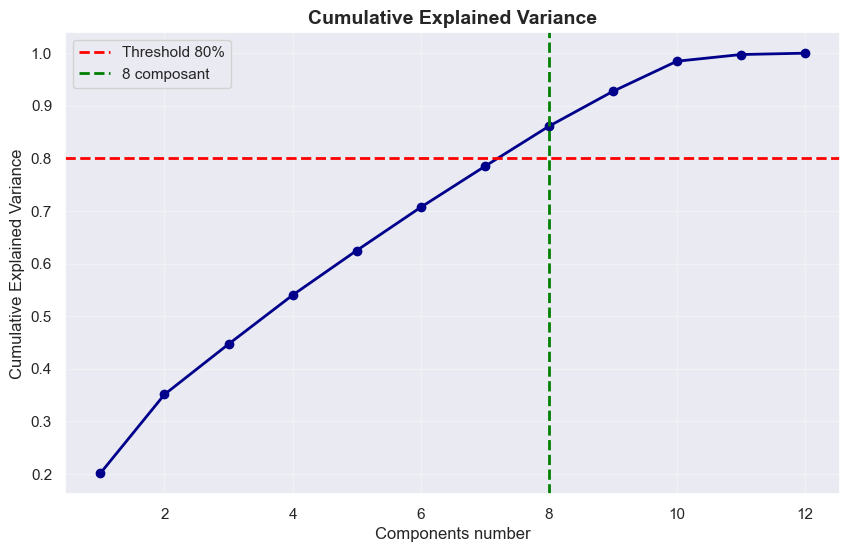


✓ optimal number of components explained for ≥80% de variance : 8


In [71]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linewidth=2, color='darkblue')
plt.axhline(y=0.80, color='red', linestyle='--', linewidth=2, label='Threshold 80%')
plt.axvline(x=n_components_80, color='green', linestyle='--', linewidth=2, label=f'{n_components_80} composant')
plt.xlabel('Components number', fontsize=12)    
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"\n✓ optimal number of components explained for ≥80% de variance : {n_components_80}")

In [ ]:
# Étape 3 : Apply the PCA with the optimal number 
pca_optimal = PCA(n_components=n_components_80)
X_train_pca = pca_optimal.fit_transform(X_train_scaled)
X_test_pca = pca_optimal.transform(X_test_scaled)

print(f"Transformation PCA applied {n_components_80} Components")
print(f"Original dimensions : {X_train_scaled.shape}")
print(f"Dimensions after PCA : {X_train_pca.shape}")
print(f"\nReduction of dimension : {X_train_scaled.shape[1]} → {X_train_pca.shape[1]} features")
print(f"total variances conserved : {cumulative_variance[n_components_80-1]:.2%}")

Transformation PCA applied 8 Components
Original dimensions : (623, 12)
Dimensions after PCA : (623, 8)

Reduction of dimension : 12 → 8 features
total variances conserved : 86.09%


---
## 4.Classification and comparison of the modeles  
** We will try now to train two models **  
1. **Modele 1** : on the original data(standardized)  
2. **Modele 2** : Transformed data with PCA  

** Objectif ** : Compare the performance and undertand the impact of PCA on the data.  

MODEL 1: Logistic Regression on Original Data (Standardized)

✓ trained model over  12 features
✓ Accuracy on the test set : 0.5843 (58.43%)

--------------------------------------------------------------------------------
Classification Report :
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

   Classical       0.88      1.00      0.93        49
     Country       0.49      0.31      0.38        54
     Hip-hop       0.47      0.48      0.48        50
        Jazz       0.46      0.44      0.45        57
        Rock       0.58      0.72      0.64        57

    accuracy                           0.58       267
   macro avg       0.57      0.59      0.58       267
weighted avg       0.57      0.58      0.57       267



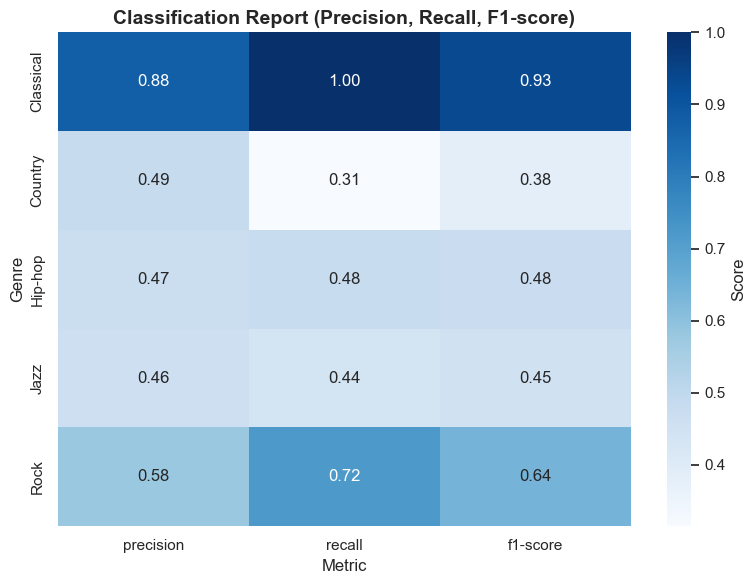

In [76]:
# Model 1: Logistic regression on the original data
print("="*80)
print("MODEL 1: Logistic Regression on Original Data (Standardized)")
print("="*80)

# Train the model (max_iter=10000, random_state=42)
model_original = LogisticRegression(max_iter=10000, random_state=42)
model_original.fit(X_train_scaled, y_train)

# Predictions
y_pred_original = model_original.predict(X_test_scaled)

# Evaluation
accuracy_original = accuracy_score(y_test, y_pred_original)
print(f"\n✓ trained model over  {X_train_scaled.shape[1]} features")
print(f"✓ Accuracy on the test set : {accuracy_original:.4f} ({accuracy_original*100:.2f}%)")

print("\n" + "-"*80)
print("Classification Report :")
print("-"*80)
print(classification_report(y_test, y_pred_original, target_names=label_encoder.classes_))

# Visualize the classification report as a heatmap
report_dict = classification_report(y_test, y_pred_original, target_names=label_encoder.classes_, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Select only the class rows (not 'accuracy', 'macro avg', etc.)
class_rows = label_encoder.classes_
metrics = ['precision', 'recall', 'f1-score']
heatmap_data = report_df.loc[class_rows, metrics]

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    cbar_kws={'label': 'Score'}
)
plt.title('Classification Report (Precision, Recall, F1-score)', fontsize=14, fontweight='bold')
plt.ylabel('Genre')
plt.xlabel('Metric')
plt.tight_layout()
plt.show()



MODÈLE 2 : Logistic Regression over PCA Data

✓model trained over 8 principal components
✓ Accuracy on the test set : 0.5431 (54.31%)

--------------------------------------------------------------------------------
Classification Report :
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

   Classical       0.87      0.98      0.92        49
     Country       0.45      0.33      0.38        54
     Hip-hop       0.39      0.38      0.38        50
        Jazz       0.41      0.35      0.38        57
        Rock       0.54      0.70      0.61        57

    accuracy                           0.54       267
   macro avg       0.53      0.55      0.54       267
weighted avg       0.53      0.54      0.53       267



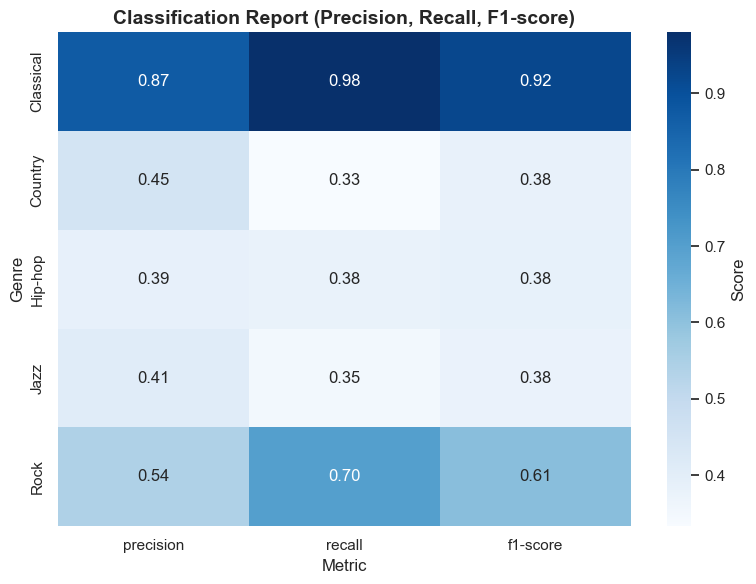

In [78]:
# Modèle 2 : logistic regression over PCA data
print("="*80)
print("MODÈLE 2 : Logistic Regression over PCA Data")
print("="*80)

# Train the model (max_iter=10000, random_state=42)
model_pca = LogisticRegression(max_iter=10000, random_state=42)
model_pca.fit(X_train_pca, y_train)

# Predictions
y_pred_pca = model_pca.predict(X_test_pca)

# Evaluation
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print(f"\n✓model trained over {X_train_pca.shape[1]} principal components")
print(f"✓ Accuracy on the test set : {accuracy_pca:.4f} ({accuracy_pca*100:.2f}%)")

print("\n" + "-"*80)
print("Classification Report :")
print("-"*80)
print(classification_report(y_test, y_pred_pca, target_names=label_encoder.classes_))


# Visualize the classification report as a heatmap
report_dict = classification_report(y_test, y_pred_pca, target_names=label_encoder.classes_, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Select only the class rows (not 'accuracy', 'macro avg', etc.)
class_rows = label_encoder.classes_
metrics = ['precision', 'recall', 'f1-score']
heatmap_data = report_df.loc[class_rows, metrics]

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    cbar_kws={'label': 'Score'}
)
plt.title('Classification Report (Precision, Recall, F1-score)', fontsize=14, fontweight='bold')
plt.ylabel('Genre')
plt.xlabel('Metric')
plt.tight_layout()
plt.show()


In [79]:
# comparison of the 2 models
print("="*80)
print("COMPARISON OF THE MODELS")
print("="*80)

comparison_data = {
    'Model': ['Original Data', 'PCA Data'],
    'Number of Features': [X_train_scaled.shape[1], X_train_pca.shape[1]],
    'Accuracy': [accuracy_original, accuracy_pca],
    'Difference': [0, accuracy_pca - accuracy_original]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n" + "="*80)
print("INTERPRETATION :")
print("="*80)

if accuracy_pca > accuracy_original:
    best_model = "PCA"
    diff = accuracy_pca - accuracy_original
    print(f"✓ The model with PCA is BETTER (+{diff:.4f} or +{diff*100:.2f}%)")
elif accuracy_original > accuracy_pca:
    best_model = "Original"
    diff = accuracy_original - accuracy_pca
    print(f"✓ The model without PCA is BETTER (+{diff:.4f} or +{diff*100:.2f}%)")
else:
    best_model = "Tie"
    print("✓ Both models have IDENTICAL performance")

print(f"\nAdvantages of PCA :")
print(f"  - Dimensionality reduction : {X_train_scaled.shape[1]} → {X_train_pca.shape[1]} features")
print(f"  - Potentially faster training time")
print(f"  - Noise and redundancy elimination")
print(f"  - Possible better generalization")
# DDetermine the best model for the next steps
if accuracy_pca >= accuracy_original:
    best_model_obj = model_pca
    best_X_full = pca_optimal.transform(scaler.transform(X))
    print(f"\n→ PCA model selected for predicting missing genres")
else:
    best_model_obj = model_original
    best_X_full = scaler.transform(X)
    print(f"\n→ Original model selected for predicting missing genres")

COMPARISON OF THE MODELS
        Model  Number of Features  Accuracy  Difference
Original Data                  12  0.584270    0.000000
     PCA Data                   8  0.543071   -0.041199

INTERPRETATION :
✓ The model without PCA is BETTER (+0.0412 or +4.12%)

Advantages of PCA :
  - Dimensionality reduction : 12 → 8 features
  - Potentially faster training time
  - Noise and redundancy elimination
  - Possible better generalization

→ Original model selected for predicting missing genres


---
## 5. Prediction of the genre null values

Now that we have selected the best model, we will:
1. Identify tracks with missing genders
2. Predict their genders using the optimal model
3. Integrate the predictions into the original DataFrame
4. Verify that the final dataset is complete

In [82]:
# Identify the indexes of tracks with missing genres
missing_genre_indices = df_work[df_work['Genre'].isnull()].index

print(f"Number of missing genres to predict: {len(missing_genre_indices)}")
print(f"Indices : {missing_genre_indices.tolist()}")

# Extract the features of the tracks with missing genres
X_missing = df_work.loc[missing_genre_indices].select_dtypes(include=[np.number])

# Ensure the columns match those used for training
X_missing = X_missing[X.columns]

print(f"\nDimensions of data to predict: {X_missing.shape}")

X_missing.head()

Number of missing genres to predict: 110
Indices : [13, 18, 22, 31, 42, 48, 57, 58, 75, 90, 105, 114, 115, 129, 130, 131, 132, 143, 202, 203, 204, 251, 270, 271, 272, 330, 331, 332, 431, 432, 433, 434, 435, 454, 458, 628, 629, 630, 631, 632, 633, 634, 635, 636, 642, 677, 678, 679, 680, 681, 682, 683, 684, 685, 686, 687, 688, 689, 690, 691, 692, 693, 694, 695, 696, 725, 729, 734, 740, 757, 816, 817, 818, 819, 820, 821, 822, 823, 824, 825, 861, 862, 863, 864, 865, 866, 867, 868, 974, 975, 976, 977, 978, 979, 980, 981, 982, 983, 984, 985, 986, 987, 988, 989, 990, 991, 992, 993, 994, 995]

Dimensions of data to predict: (110, 12)


,Tempo,Dynamics Range,Vocal Presence,Percussion Strength,String Instrument Detection,Electronic Element Presence,Rhythm Complexity,Drums Influence,Distorted Guitar,Metal Frequencies,Ambient Sound Influence,Instrumental Overlaps
13,104.389822,65.826509,45.855410,55.655533,76.058845,55.625315,25.312585,59.202818,0.920308,0.000000,94.308889,27.441046
18,101.367152,47.843370,93.230347,67.101777,20.932163,50.772288,30.348312,62.950165,64.462755,68.971944,21.690071,94.717315
22,85.130539,55.707108,81.149615,21.473425,14.959208,61.017283,64.000152,43.332846,70.455879,79.053598,20.420619,99.499498
31,121.100952,71.769727,49.609529,82.539647,47.670106,119.460607,68.812707,83.727876,95.307620,95.779062,2.883916,19.230684
42,93.546825,44.563761,56.587554,99.546134,109.735122,30.128106,48.392807,81.888793,97.200948,100.000000,16.380240,55.483399


In [83]:
# Apply the same transformation as for training
X_missing_scaled = scaler.transform(X_missing)

# As the accuracy of the original data is higher than the PCA data, we will use the original data model to predict the missing genres
X_missing_transformed = X_missing_scaled
print("Missing data standardized (without PCA)")

# Predict the missing genres
predicted_genres_encoded = best_model_obj.predict(X_missing_transformed)
print("predicted_genres_encoded", predicted_genres_encoded)

# Decode the predictions
predicted_genres = label_encoder.inverse_transform(predicted_genres_encoded)

print(f"\n✓ Predictions made for {len(predicted_genres)} tracks")
print("\nPredicted genres:")
for idx, genre in zip(missing_genre_indices, predicted_genres):
    print(f"  Index {idx}: {genre}")

Missing data standardized (without PCA)
predicted_genres_encoded [0 1 1 2 4 3 3 3 2 2 4 4 4 2 4 1 2 3 2 4 2 4 0 3 4 3 0 2 0 3 0 1 3 4 4 4 1
 0 2 1 3 0 0 1 4 1 2 3 0 3 4 3 0 1 4 1 2 4 1 3 2 0 0 1 1 4 3 0 1 2 3 1 1 4
 1 4 3 3 1 1 4 0 4 0 0 4 0 1 2 4 0 4 3 0 4 4 0 1 0 3 0 3 2 4 3 2 4 2 2 0]

✓ Predictions made for 110 tracks

Predicted genres:
  Index 13: Classical
  Index 18: Country
  Index 22: Country
  Index 31: Hip-hop
  Index 42: Rock
  Index 48: Jazz
  Index 57: Jazz
  Index 58: Jazz
  Index 75: Hip-hop
  Index 90: Hip-hop
  Index 105: Rock
  Index 114: Rock
  Index 115: Rock
  Index 129: Hip-hop
  Index 130: Rock
  Index 131: Country
  Index 132: Hip-hop
  Index 143: Jazz
  Index 202: Hip-hop
  Index 203: Rock
  Index 204: Hip-hop
  Index 251: Rock
  Index 270: Classical
  Index 271: Jazz
  Index 272: Rock
  Index 330: Jazz
  Index 331: Classical
  Index 332: Hip-hop
  Index 431: Classical
  Index 432: Jazz
  Index 433: Classical
  Index 434: Country
  Index 435: Jazz
  Index 454:

In [84]:
# Integrate the prediction in the original dataframe
df_work.loc[missing_genre_indices, 'Genre'] = predicted_genres

print("Predictions integrated into the original DataFrame")
print("\n" + "="*80 + "\n")

# Check that there are no more missing values
missing_after = df_work['Genre'].isnull().sum()
print(f"Missing values after prediction: {missing_after}")

if missing_after == 0:
    print("✓ SUCCESS: The dataset is now complete!")
else:
    print(f"⚠ WARNING: There are still {missing_after} missing values")

# Display the final distribution of genres
print("\n" + "="*80 + "\n")
print("Final distribution of genres:")
print(df_work['Genre'].value_counts().sort_index())

Predictions integrated into the original DataFrame


Missing values after prediction: 0
✓ SUCCESS: The dataset is now complete!


Final distribution of genres:
Genre
Classical    185
Country      201
Hip-hop      186
Jazz         211
Rock         217
Name: count, dtype: int64


In [85]:
# Save the complete dataset
output_file = 'music_dataset_complete.csv'
df_work.to_csv(output_file, index=False)
print(f"\n✓ Complete dataset saved: {output_file}")


✓ Complete dataset saved: music_dataset_complete.csv
